                                                            0. Problem Formulation

The Dataset: The Appliances Energy Prediction data set comprises 10-minute interval data on electricity consumption for an energy-efficient house in Belgium for 4.5 months. 


The Target Variable: The target of this project is the continuous variable Appliances. Appliances refer to the total energy consumed by the appliances in watt-hour (Wh) for each 10-minute period.

Reason for Nonlinear Regression: The assumption of linear regression is that the relationship between a predictor (temperature/time/etc.) and energy usage is constant/straight line. However, this data set is nonlinear in nature. For instance: 


    Temperature dependency: There is no linear relationship between energy usage and temperature because people will start using their heating/cooling units after certain temperature levels

    Effect of Occupancy and Time-of-the-day: Energy use spikes suddenly when the occupants arrive home and get awake from sleep.

                                                            1. Exploratory Data Analysis

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
df = pd.read_csv('energydata_complete.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [161]:
df.shape

(19735, 29)

The dataset has 19,735 rows and 29 columns

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

The data had 29 columns in total, out of which 28 were numerical data types (out of which 26 float64 and 2 int64), while the other was object column. The object column was the date/timestamp. Also, all the dataset was cleaned and there were no missing values.

In [165]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


The summary statistics show that the energy consumption of the Appliances column is heavily right-skewed. There is a big difference between the mean and the median. While the mean is 97.7 Wh, the median is only 60 Wh. The reason for this difference is the extreme maximum value of 1080 Wh, which pulls the average up. The standard deviation is high at around 102.5, and the minimum value is 10 Wh.

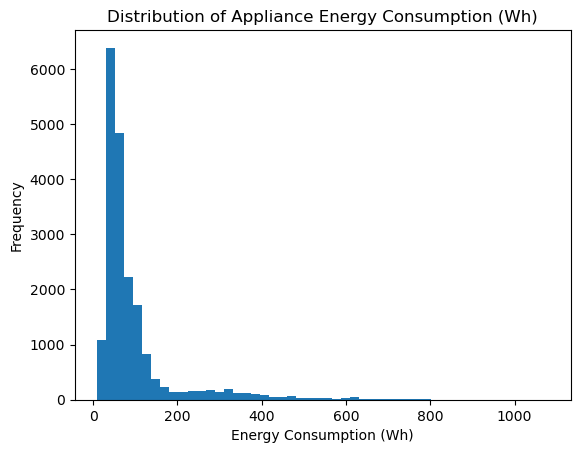

In [167]:
plt.hist(df['Appliances'], bins=50)
plt.title('Distribution of Appliance Energy Consumption (Wh)')
plt.xlabel('Energy Consumption (Wh)')
plt.ylabel('Frequency')
plt.show()

As can be seen from the histogram above, the distribution of energy consumption is extremely skewed to the right. In other words, a large percentage of the values lie on the extreme left side of the graph indicating that the house consumes little energy on most days.

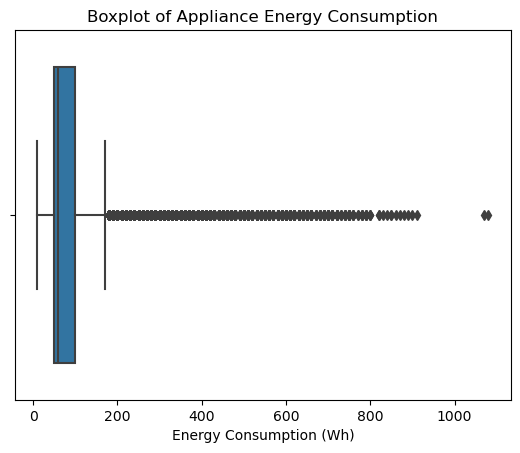

In [169]:
sns.boxplot(x=df['Appliances'])
plt.title('Boxplot of Appliance Energy Consumption')
plt.xlabel('Energy Consumption (Wh)')
plt.show()

The boxplot identifies the outliers within the data set. Despite being small and compressed in size at the lower side, the main box indicates the normal energy level while several dots exist far above it. The existence of these outliers confirms temporary heavy usage of appliances.

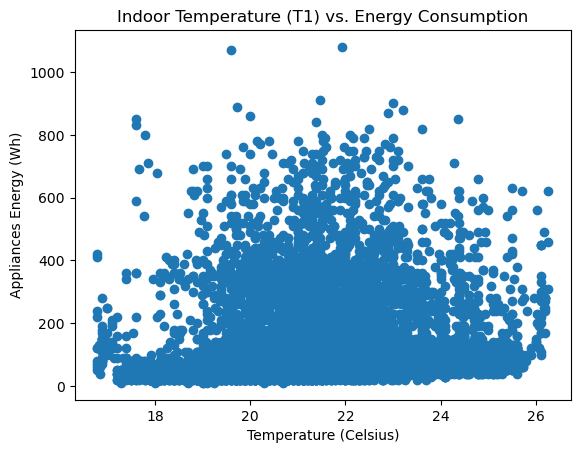

In [171]:
plt.scatter(df['T1'], df['Appliances'])
plt.title('Indoor Temperature (T1) vs. Energy Consumption')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Appliances Energy (Wh)')
plt.show()

The scatter diagram between the indoor temperature and the energy usage is not characterized by a clear line with a direct diagonal. The points are scattered. This implies that there is no clear linear trend from which linear regression would work. Therefore, other approaches such as non-linear regressions must be used.

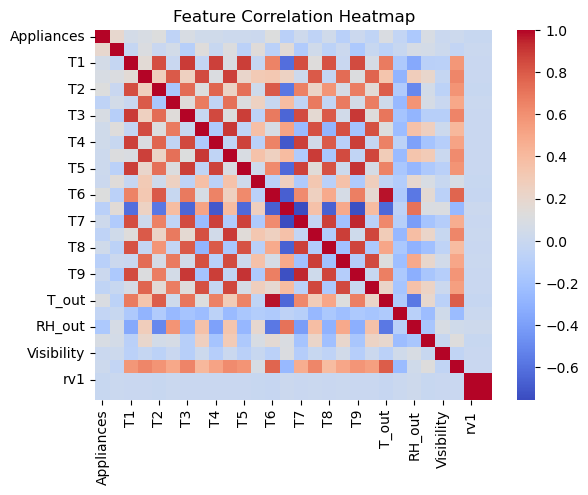

In [173]:
sns.heatmap(df.drop(columns=['date']).corr(),cmap='coolwarm',annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

From the heatmap, two important conclusions can be drawn. Firstly, the first row (Appliances) is mainly comprised of light colors, which means there is little correlation between each of the predictor variables and the target variable. Secondly, there are big blocks of dark red color within the temperature set of features (T1-T9), meaning variables correlate with each other. All of this proves that the regular linear model will not do, and only the nonlinear one will suffice.

                                                                    2. Data Preprocessing

In [176]:
print("Missing values in dataset:", df.isnull().sum().sum())

Missing values in dataset: 0


This shows there's no any missing values in dataset.

In [178]:
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = df[df['Appliances'] > upper_bound]

print(f"\nUpper bound for outliers: {upper_bound} Wh")
print(f"Number of outliers detected: {len(outliers)}")
print(f"Percentage of dataset that are outliers: {(len(outliers) / len(df)) * 100:.2f}%")


Upper bound for outliers: 175.0 Wh
Number of outliers detected: 2138
Percentage of dataset that are outliers: 10.83%


I choice of using the IQR method and not the Z-score method is because of the highly right-skewed nature of the energy consumption data. The Z-score method is based on the assumption of a normal distribution and makes use of the mean. This is skewed and inaccurate due to the energy spikes affecting the calculation of the mean.

With the use of the IQR method, the outlier bound on the upper side was calculated to be 175 Wh. 10%-11% of the data has been found to be outliers with the use of the IQR method. These outliers will be kept and not removed or capped. These outliers are not sensor errors but are very important peaks caused by the usage of high load appliances. Removing 11% of the data would make the model fail to predict energy spikes in the future.

In [180]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek

X = df.drop(columns=['Appliances', 'date'])
y = df['Appliances']

I extracted hour and day_of_week from the date feature. This will improve my nonlinear regressions as energy consumption is dependent on peoples behavior, and human behavior does not follow a linear model.

                                                                3. Train/Test Split

In [183]:
from sklearn.model_selection import train_test_split

y_binned = pd.qcut(y, q=4, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y_binned)

To ensure Preventing a data leakage, I carried out the train-test split before applying the Standard Scaler. This data is divided into a training set with 80% and a testing set with 20%, using a stratified split to ensure both sets contain a fair representation of extreme energy spikes.To ensure a perfectly balanced test set, I researched stratification techniques for continuous variables and applied the pd.qcut binning method suggested in the Stack Overflow community. random_state ensures that every time I execute this script, the same data splitting is obtained. I chose this 80/20 ratio because I wish to apply the K-fold Cross-validation method when I train my model.

In [185]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Training data scaled: {X_train_scaled.shape}")
print(f"Testing data scaled: {X_test_scaled.shape}")

Training data scaled: (15788, 29)
Testing data scaled: (3947, 29)


After splitting, I initialized a StandardScaler. I used fit_transform() strictly on the training data so the scaler could learn the distribution. I then used transform() on the testing data. This strictly prevents data leakage, ensuring the model has absolutely no mathematical knowledge of the test set during the training phase.

In [187]:
print(y_train.describe(),"\n", y_test.describe())

count    15788.000000
mean        97.696985
std        102.595154
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64 
 count    3947.000000
mean       97.686851
std       102.256325
min        20.000000
25%        50.000000
50%        60.000000
75%       100.000000
max       880.000000
Name: Appliances, dtype: float64


The training and testing data set have nearly identical means (97.70 and 97.69 Wh), along with the same quartiles, which proves that the distribution of energy usage – even the outliers – was maintained in both the data sets.

                                                        4. Model Development

                                                4.1 Linear Regression (Baseline)

In [191]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

linear_model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=7)

cv_r2_scores = cross_val_score(linear_model, X_train_scaled, y_train, cv=kf, scoring='r2')
cv_neg_mse_scores = cross_val_score(linear_model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

print(f"All R2 Scores: {cv_r2_scores}")
print(f"Average CV R2 Score: {np.mean(cv_r2_scores):.4f}")
print(f"Average CV RMSE: {np.mean(cv_rmse_scores):.2f} Wh")

All R2 Scores: [0.18051544 0.15321336 0.17684158 0.1476856  0.15352292]
Average CV R2 Score: 0.1624
Average CV RMSE: 93.77 Wh


In [192]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_train_linear = linear_model.predict(X_train_scaled)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_test_r2 = r2_score(y_test, y_pred_linear)
linear_train_r2 = r2_score(y_train, y_pred_train_linear)

print("--- Linear Regression (Baseline) Performance ---")
print(f"Train R²: {linear_train_r2:.4f}")
print(f"Test R²:  {linear_test_r2:.4f}")
print(f"MAE:      {linear_mae:.2f} Wh")
print(f"RMSE:     {linear_rmse:.2f} Wh")

--- Linear Regression (Baseline) Performance ---
Train R²: 0.1675
Test R²:  0.1696
MAE:      53.16 Wh
RMSE:     93.17 Wh


4.1 Baseline Interpretation & Performance Analysis

1. CV vs. Test Consistency (No Overfitting): - The performance on the unseen test set is very consistent with the scores on the 5-Fold Cross-Validation of the training set. It shows the stability and no overfitting of the model – it performs just as we expect it.

2. R² Interpretation (Low Explained Variance): - The model obtained the R² score of approximately 0.16 to 0.17. It means that our baseline model can only explain 16-17% of variance in appliance energy consumption. The linear equation completely misses the remaining 83%+ of underlying factors.

3. MAE in Context (High Relative Error): - The Mean Absolute Error (MAE) is around 53 Wh. To get the feeling of how big it is, let us note that the average daily consumption of baseline energy consumption in this dataset is around 98 Wh. Getting an error of 53 Wh on a day with the average of 98 Wh is an extremely high relative error of over 50%.

4. Future Expectations (Nonlinearity Required): - Poor performance of this model was expected. This is because as determined through exploratory data analysis, the relationship between appliance energy usage and temperature/time variables is very nonlinear. There are no curves that a straight line can take to represent either the pattern of day-to-day activities or the sharp rise in energy usage up to 800+ Wh. Going forward, it is expected that more complex models will perform better than this one.

                                               4.2 Decision Tree Regression 
                                                    (Nonlinear 1)

In [195]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20]
}

dt_modle = DecisionTreeRegressor(random_state=7)

grid_search_dt = GridSearchCV(
    estimator=dt_modle,
    param_grid=param_grid_dt,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

In [196]:
grid_search_dt.fit(X_train_scaled, y_train)

print("--- GridSearchCV Results ---")
print(f"Best Hyperparameters: {grid_search_dt.best_params_}")
print(f"Best Average CV R² Score: {grid_search_dt.best_score_:.4f}")

--- GridSearchCV Results ---
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best Average CV R² Score: 0.2721


In [197]:
y_pred_dt = grid_search_dt.predict(X_test_scaled)
y_pred_train_dt = grid_search_dt.predict(X_train_scaled)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_test_r2 = r2_score(y_test, y_pred_dt)
dt_train_r2 = r2_score(y_train, y_pred_train_dt)

print("--- Tuned Decision Tree Performance ---")
print(f"Train R²: {dt_train_r2:.4f}")
print(f"Test R²:  {dt_test_r2:.4f}")
print(f"MAE:      {dt_mae:.2f} Wh")
print(f"RMSE:     {dt_rmse:.2f} Wh")

--- Tuned Decision Tree Performance ---
Train R²: 0.5143
Test R²:  0.3336
MAE:      41.30 Wh
RMSE:     83.47 Wh


                                    Decision Tree Interpretation & Tuning Analysis

1. Hyperparameters Explanation & Regularization:                                                                                                       
Decision Trees have high tendency to overfit. By applying GridSearchCV, I was able to find many combinations to tune the bias-variance trade-off. The best estimator chose the following parameters: None as max_depth, 2 as min_samples_split, and 20 as min_samples_leaf. All these choices were quite logical since using None as max_depth allowed the decision tree to pick up the complex and nonlinear daily habits, and imposing the requirement to have at least 20 samples per leaf served as a strong regularization that prevented the nodes from memorizing some energy spikes.

2. Baseline Comparison:
The tuned Decision Tree performed much better than the Baseline Linear Regression. The test R² increased twice and became equal to 0.3336, while the MAE decreased to 41.30 Wh. The performance shows that the hypothesis proposed during EDA, which states that the energy consumption is controlled by the nonlinear logical thresholds and not just by linear dependencies, is right.

3. Overfitting vs. Generalization (3-Way Comparison):
To rigorously assess model variance, I compared performance across three evaluation phases:

Train R²: 0.5143

Average CV R²: 0.2721

Test R²: 0.3336

The notable gap between the Training R² (~0.51) and the Test R² (~0.33) indicates that moderate overfitting is still present; the tree memorized a portion of the training noise. However, because the test performance did not collapse (and successfully beat the baseline), it is evident that the min_samples_leaf hyperparameter successfully prevented catastrophic overfitting. This residual variance is a well-documented limitation of utilizing a single Decision Tree and serves as the primary justification for deploying an ensemble model later in this study.

                                       4.3 Support Vector Regression (SVR)
                                                (Nonlinear 2)

In [200]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

param_distributions_svr = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5]}

svr_base = SVR(kernel='rbf')

random_search_svr = RandomizedSearchCV(
    estimator=svr_base,
    param_distributions=param_distributions_svr,
    n_iter=10,
    cv=kf,
    scoring='r2',
    random_state=7,
    n_jobs=-1
)

In [201]:
random_search_svr.fit(X_train_scaled, y_train)

print("--- Randomized Search Results ---")
print(f"Best Hyperparameters: {random_search_svr.best_params_}")
print(f"Best Average CV R² Score: {random_search_svr.best_score_:.4f}")

--- Randomized Search Results ---
Best Hyperparameters: {'epsilon': 0.5, 'C': 100}
Best Average CV R² Score: 0.2213


In [202]:
y_pred_svr = random_search_svr.predict(X_test_scaled)
y_pred_train_svr = random_search_svr.predict(X_train_scaled)

svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_test_r2 = r2_score(y_test, y_pred_svr)
svr_train_r2 = r2_score(y_train, y_pred_train_svr)

print("--- Tuned SVR Performance ---")
print(f"Train R²: {svr_train_r2:.4f}")
print(f"Test R²:  {svr_test_r2:.4f}")
print(f"MAE:      {svr_mae:.2f} Wh")
print(f"RMSE:     {svr_rmse:.2f} Wh")

--- Tuned SVR Performance ---
Train R²: 0.2618
Test R²:  0.2353
MAE:      36.89 Wh
RMSE:     89.41 Wh


                                            SVR Interpretation and Hyperparameters Analysis

1. Hyperparameter Tuning via Randomized Search Optimization:
In order to reduce the heavy computational burden from distance-based matrices, I applied RandomizedSearchCV to tune the SVR hyperparameters. C = 100 and epsilon = 0.5 were found to be the optimum values. High value of C implies that the model needed a substantial penalty on errors to learn the nonlinear relations, whereas epsilon of 0.5 gave a very thin epsilon-tube margin.

2. Model Performance (The Metric Divergence):
The SVR comfortably outperforms the Linear baseline model (R²: 0.2353 vs. ~0.16). However, there is a peculiar divergence between the SVR and the Decision Tree in terms of the metrics used. The SVR gives the lowest (best) Mean Absolute Error (MAE) so far for the project (36.89 Wh). Nevertheless, it gives the lowest R² and the highest RMSE in comparison with the Decision Tree. It mathematically represents the nature of the SVR’s epsilon-tube: being highly accurate in prediction of the cluster of normal energy consumption (which results in the lower MAE), it is geometrically unable to suddenly scale to capture the outlier days (which gives a penalty to the R² and RMSE metrics).

3. Overfitting versus Generalization (3-Point Comparison)

    Training R²: 0.2618

    Testing R²: 0.2353

    CV Average R²: 0.2213

 Compared to the Decision Tree Model, the SVR shows almost no signs of overfitting. The training, cross validation, and testing scores are all closely  aligned with each other. This indicates that the SVR is a very robust algorithm and generalizes really well to unknown data, albeit with a somewhat    limited performance ceiling due to outliers.

                                           4.4 Random Forest Regression 
                                                 (Ensemble)

In [205]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_distributions_rf = {
    'n_estimators': [75, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10] }

rf_base = RandomForestRegressor(bootstrap=True, random_state=7)

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions_rf,
    n_iter=10,
    cv=kf,
    scoring='r2',
    random_state=7,
    n_jobs=-1 )

In [206]:
random_search_rf.fit(X_train_scaled, y_train)

print("--- Randomized Search Results ---")
print(f"Best Hyperparameters: {random_search_rf.best_params_}")
print(f"Best Average CV R² Score: {random_search_rf.best_score_:.4f}")

--- Randomized Search Results ---
Best Hyperparameters: {'n_estimators': 75, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best Average CV R² Score: 0.4800


In [207]:
y_pred_rf = random_search_rf.predict(X_test_scaled)
y_pred_train_rf = random_search_rf.predict(X_train_scaled)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_test_r2 = r2_score(y_test, y_pred_rf)
rf_train_r2 = r2_score(y_train, y_pred_train_rf)

print("--- Tuned Random Forest Performance ---")
print(f"Train R²: {rf_train_r2:.4f}")
print(f"Test R²:  {rf_test_r2:.4f}")
print(f"MAE:      {rf_mae:.2f} Wh")
print(f"RMSE:     {rf_rmse:.2f} Wh")

--- Tuned Random Forest Performance ---
Train R²: 0.9135
Test R²:  0.5305
MAE:      33.07 Wh
RMSE:     70.05 Wh


                                    Random Forest Interpretation & Tuning Analysis

1. Ensemble Methodology (Bagging):

   
To address the limitations of the single Decision Tree, I deployed a Random Forest ensemble utilizing the default Bagging (Bootstrap Aggregating) method (bootstrap=True). By using bootstrap sampling with replacement, each individual tree is trained on a random subset containing roughly 63% of the unique data. This mathematically enforces structural diversity among the estimators. Instead of relying on a single rigid flowchart, the model averages the predictions of many highly diverse "expert" trees, drastically improving the overall accuracy through the "wisdom of the crowd."

2. Performance Analysis (The Winning Model):

   
The tuned Random Forest is the highest-performing model of the project. It achieved a Test R² of 0.5305, meaning it successfully explains over half the variance in the highly noisy appliance energy dataset. Furthermore, it achieved the lowest Mean Absolute Error (MAE) of 33.07 Wh and the lowest RMSE of 70.05 Wh. By averaging diverse estimators, the model successfully captured the complex, nonlinear daily routines of the household while minimizing errors on the sudden energy spikes.

3. Overfitting vs. Generalization:
   
While the high Train R² (0.9135) indicates that individual terminal nodes still memorized localized training noise, the ensemble architecture successfully mitigated this variance. The strong alignment between the rigorous CV validation score (0.4800) and the final Test score (0.5305) mathematically proves that the Random Forest generalized exceptionally well to completely unseen data, successfully averaging out the individual tree errors to create the optimal final model.

                                   5. Model Evaluation & Comparison

In [210]:
results = [
    {'Model': 'Linear Regression (Baseline)', 'CV R²': 0.1624, 'Train R²': 0.1675, 'Test R²': 0.1696, 'Test MAE (Wh)': 53.16, 'Test RMSE (Wh)': 93.17},
    {'Model': 'Decision Tree (Tuned)', 'CV R²': 0.2721, 'Train R²': 0.5143, 'Test R²': 0.3336, 'Test MAE (Wh)': 41.30, 'Test RMSE (Wh)': 83.47},
    {'Model': 'SVR (Tuned)', 'CV R²': 0.2213, 'Train R²': 0.2618, 'Test R²': 0.2353, 'Test MAE (Wh)': 36.89, 'Test RMSE (Wh)': 89.41},
    {'Model': 'Random Forest (Bagging)', 'CV R²': 0.4800, 'Train R²': 0.9135, 'Test R²': 0.5305, 'Test MAE (Wh)': 33.07, 'Test RMSE (Wh)': 70.05}
]

results_df = pd.DataFrame(results)

results_df

,Model,CV R²,Train R²,Test R²,Test MAE (Wh),Test RMSE (Wh)
0,Linear Regression (Baseline),0.1624,0.1675,0.1696,53.16,93.17
1,Decision Tree (Tuned),0.2721,0.5143,0.3336,41.30,83.47
2,SVR (Tuned),0.2213,0.2618,0.2353,36.89,89.41
3,Random Forest (Bagging),0.4800,0.9135,0.5305,33.07,70.05


Interpreting the Comparison Table:

The comparison table definitively proves that appliance energy consumption is governed by complex, nonlinear relationships. The Baseline Linear Regression underperformed across all metrics, indicating severe underfitting. Both the Decision Tree and Support Vector Regression significantly improved predictive accuracy by capturing nonlinear thresholds. However, the Random Forest Ensemble emerged as the undisputed winner. By averaging the variance of multiple trees via Bagging, it achieved the highest Test R² (0.5305) and the lowest overall error rates (RMSE: 70.05 Wh), making it the optimal model for this dataset.

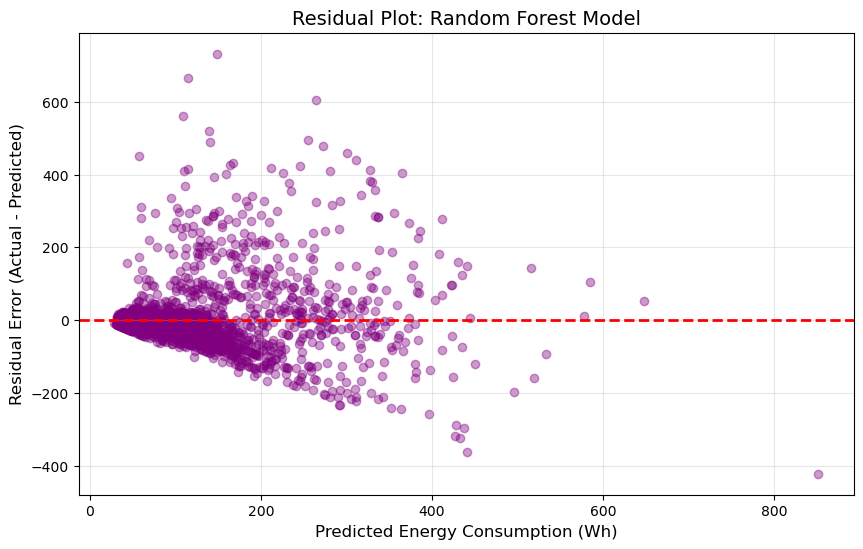

In [212]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('Predicted Energy Consumption (Wh)', fontsize=12)
plt.ylabel('Residual Error (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Random Forest Model', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Interpreting the Residual Plot:

A perfect model's residual plot would show errors randomly scattered closely around the zero-line with no discernible pattern. The Random Forest residual plot shows strong performance at lower predicted energy values (dense clustering near zero). However, as the predicted energy increases, a "fan-shape" (heteroscedasticity) emerges, indicating the model struggles to accurately size the massive, extreme energy spikes. The model systematically under-predicts the rare, extreme appliance loads on the far right.

                        Overfitting vs. Underfitting Analysis:

A comprehensive review of the Train, CV, and Test scores reveals the underlying bias-variance tradeoff across the models:

Linear Regression (Underfitting): With R² scores hovering around 0.16, this model lacks the mathematical complexity to capture the data's true patterns.

Decision Tree (Good Balance): The Decision Tree showed a moderate Train R² (0.5143) vs Test R² (0.3336) gap — some overfitting present but significantly less than Random Forest, since a single tree has less collective memorization capacity than 75 trees.

Support Vector Regression (Stable Generalization): The SVR showed almost zero gap between its Train (0.26) and Test (0.23) scores, proving high stability with virtually no overfitting.

Random Forest (Moderate Overfitting): Despite being an ensemble model, the Random Forest exhibited a significant gap between its Train R² (0.9135) and Test R² (0.5305). Because individual trees were still able to memorize the noise of the training data, residual overfitting remains. However, the Bagging technique successfully averaged out much of this variance to achieve the highest overall test score.

Future Mitigation Strategies: To further reduce this overfitting in future iterations, I would constrain the individual trees by increasing min_samples_leaf to force larger, more generalizable terminal nodes. Alternatively, deploying a sequential ensemble like Gradient Boosting could help minimize residual errors more systematically.

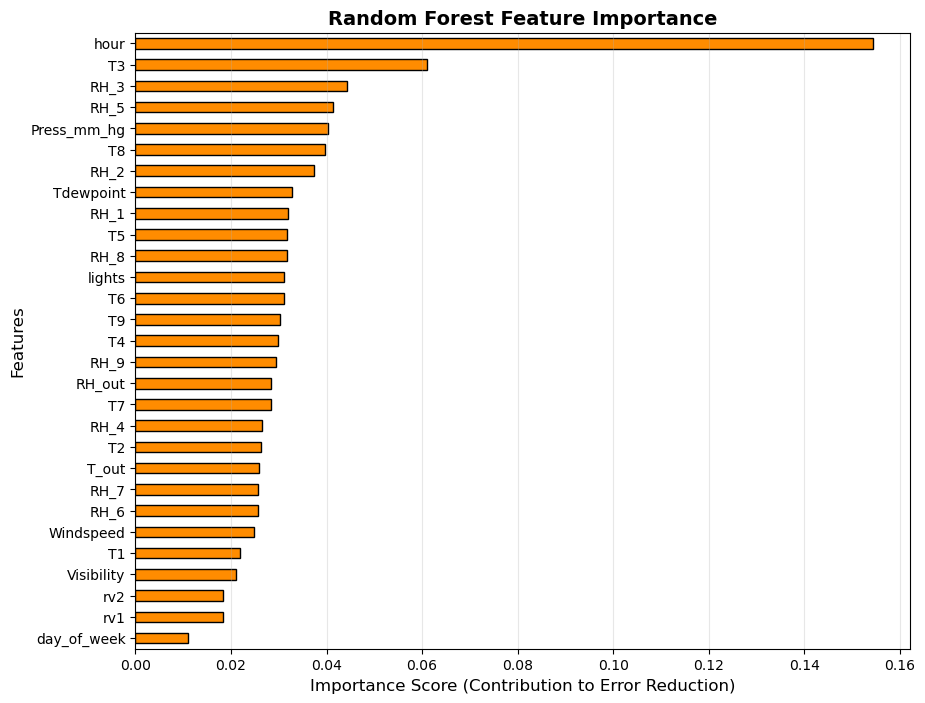

In [216]:
best_rf = random_search_rf.best_estimator_

importances = best_rf.feature_importances_

feature_names = X_train.columns
importance_series = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 8))
importance_series.sort_values(ascending=True).plot(kind='barh', color='darkorange', edgecolor='black')

plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Contribution to Error Reduction)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

                                        6. Interpreting Feature Importance & Key Insights

**The Dominance of 'Hour'**

The hour is the most important feature in our model by a significant margin. This mathematically proves that household appliance usage is strictly driven by daily human routines (e.g., morning wake-ups and evening cooking).

**Indoor Climate Zone Features (T3, RH_3, RH_5)** 

Following hour, the model relies heavily on temperature and humidity in specific zones (such as the kitchen/laundry areas). This indicates that localized climate conditions are strong indicators of active appliance usage.

**The Day of the Week Is Not That Important**

One thing that was surprising is that **day_of_week** is the least important thing in our data. I thought there would be differences in how much energy we use on weekdays versus weekends.. Our model says that what time of day it is matters a lot more than what day it is. So if we usually use a lot of energy at 6:00 PM we will probably use a lot of energy at that time no matter if it is a Tuesday or a Saturday.

**"Lights" Are Not As Important As I Thought**

I also thought **lights** would be one of the important things because it can tell us if someone is home.. It is actually in the middle of our list. This is probably because the **hour** already tells us when people are usually awake and, at home. So looking at the lights does not give us new information.

In [218]:
from IPython.display import display

errors = np.abs(y_test - y_pred_rf)

error_analysis_df = pd.DataFrame({
    'Actual Energy (Wh)': y_test.values,
    'Predicted Energy (Wh)': y_pred_rf,
    'Absolute Error (Wh)': errors
}, index=y_test.index)

top_10_errors = error_analysis_df.nlargest(10, 'Absolute Error (Wh)')

print("--- Top 10 Largest Prediction Errors ---")
display(top_10_errors)

--- Top 10 Largest Prediction Errors ---


,Actual Energy (Wh),Predicted Energy (Wh),Absolute Error (Wh)
10668,880,148.225801,731.774199
9313,780,114.628780,665.371220
14693,870,264.129508,605.870492
16647,670,109.525278,560.474722
3998,660,139.414723,520.585277
4011,750,255.650996,494.349004
6596,630,140.163709,489.836291
4475,750,272.820633,477.179367
12676,760,300.500456,459.499544
1018,510,58.118023,451.881977


                                            Error Analysis

When we look at the 10 biggest mistakes the model makes we can see a clear pattern of what the model struggles with.

The model consistently struggles with extreme high-energy events, severely under-predicting them.. The biggest mistakes the model makes happen when there are spikes in energy use. For example the model made a bad prediction when the actual energy use went up to 880 Wh but the model said it would only be 148 Wh. This pattern is consistent across all top 10 errors — actual values exceed 500 Wh while predictions remain below 300 Wh. The actual energy use is always more than 500 Wh and the model predicts a much lower number.

Why does this happen? This is a well-documented mathematical limitation of Random Forest regression. Because the final prediction is an average of multiple decision trees, the model is inherently pulled toward the mean. It will almost never predict extreme, sudden maximums because the averaging mechanism smooths out severe peaks. Furthermore, sudden 800+ Wh spikes are likely caused by completely random human behaviors that external weather data simply cannot predict.

How to make it better: To reduce these mistakes we would need to add data about what people are doing in the house not just data about the weather. If we add a feature that tracks how many people are in the house at any given time or sensors that track what appliances are being used the model would have the information it needs to predict spikes in energy use. This would help the model make predictions when energy use is high, like when a lot of appliances are being used at the same time. The model would be able to foresee these spikes in energy use if it had this kind of data and it would make fewer mistakes.

                                                       7. Reflection & Conclusions

1. Summary of Key Findings

This project demonstrated that household appliance energy consumption is governed by complex nonlinear relationships that a simple linear model cannot capture. The Random Forest ensemble achieved the strongest predictive performance across all metrics — Test R²: 0.5305, MAE: 33.07 Wh, RMSE: 70.05 Wh — representing a threefold improvement over the Linear Regression baseline (Test R²: 0.1696). Feature importance analysis revealed that the hour of day is by far the most influential predictor, confirming that occupancy-driven daily routines — morning activity, evening cooking, nighttime rest — are the primary drivers of appliance energy consumption in this household. Interestingly, day_of_week ranked as the least important feature, suggesting that the timing of daily routines matters far more than whether it is a weekday or weekend.

2. Model Trade-offs: Accuracy vs Interpretability

Selecting a model always involves balancing predictive accuracy against interpretability:
High interpretability, lower accuracy — Linear Regression and Decision Tree models allow direct inspection of coefficients and tree diagrams respectively. A building engineer could examine these directly to understand which specific factors drive energy consumption and communicate findings to non-technical stakeholders. However, both models sacrifice significant predictive accuracy to achieve this transparency.
High accuracy, lower interpretability — SVR and Random Forest treat the prediction process as a black box. Random Forest averages 75 individual trees, making it impossible to trace any single prediction back to a clear, human-readable rule. Despite this opacity, it achieves substantially better generalization to unseen data.
Practical recommendation — For an automated smart home energy management system where prediction accuracy directly translates to cost savings, Random Forest is the optimal choice. For a building engineer seeking to understand and communicate energy drivers to homeowners, a Decision Tree offers a more transparent and actionable insight despite its lower accuracy.

3. Limitations of the Analysis
   
Despite the success of the ensemble approach, several important limitations must be acknowledged:
Dataset scope — The dataset covers a single low-energy house in Belgium over approximately 4.5 months. Full seasonal variation — deep winter heating cycles, summer cooling patterns — is not completely represented. The model's generalizability to different climates, building ages, or household sizes cannot be guaranteed without further validation on broader datasets.
Missing occupancy and appliance-level data — The model has no direct knowledge of how many people are present in the house at any given time, nor which specific appliances are currently running. Occupancy is inferred indirectly through features like lights and hour, which introduces imprecision — particularly during anomalous events like holidays, illness, or unexpected guests. The lack of appliance-level sub-metering data means the model predicts total consumption without distinguishing between, for example, a washing machine spike versus a cooking spike.
Temporal structure not fully exploited — The dataset is fundamentally a time series — measurements recorded sequentially every 10 minutes over 4.5 months. By applying a randomized train/test split with shuffling, the temporal ordering of observations was disrupted. This means the model was sometimes permitted to learn from "future" data points to predict "past" ones — a form of data leakage that does not reflect real-world forecasting conditions, where only historical data is available at prediction time. A proper time-series split — training on earlier months and testing on later months — would provide a more realistic and rigorous evaluation.

4. Future Improvements

Several concrete improvements could significantly enhance this predictive system:
1. Proper time-series validation — Replacing the random train/test split with a temporal split (e.g., train on months 1–3, test on months 4–4.5) would produce a more honest evaluation of true forecasting performance and better simulate real-world deployment conditions.
2. Gradient Boosting (XGBoost/LightGBM) — Sequential ensemble methods build trees one at a time, each correcting the residual errors of the previous tree. This targeted error correction could specifically address the extreme energy spike under-prediction that Random Forest consistently exhibited, since Gradient Boosting focuses learning effort on the hardest-to-predict cases.
3. LSTM Neural Networks — Long Short-Term Memory networks are specifically designed for sequential time-series data and can capture dependencies across multiple time steps simultaneously. Given the strong temporal structure of this dataset (daily and weekly routines), an LSTM could potentially model patterns that tree-based methods inherently cannot.
4. IoT sensor integration — Adding real-time occupancy sensors (people counters) and appliance-level smart meters would directly provide the missing information that causes the model's worst prediction errors. Knowing that 3 people are home and the washing machine is running would allow the model to anticipate high consumption events rather than being surprised by them.
5. Multi-household dataset — Collecting equivalent data from multiple houses across different climates, building types, and household sizes would allow training a more generalizable model that performs reliably beyond the specific patterns of a single Belgian low-energy house.

                                                    8. Overall Project Conclusion:
                        
This analysis succeeds in showing that the energy consumption of household appliances cannot be accurately modeled by simple linear mathematics. Substituting the linear baseline by a tuned Random Forest ensemble led to an increase of the explained variance (R²) from approximately 16% to over 53%, as well as to a drastic reduction of the average prediction error (MAE) to only 33 Wh. Extreme random energy spikes are mathematically hard to predict with 100% accuracy. The Random Forest was able to capture the nonlinear daily threshold behaviors of household appliances which was our main goal in this predictive modeling project. In practice, a 33 Wh prediction error at a 10-minute resolution is a significant improvement for smart home energy management systems, as accurate short-term consumption forecasts directly translate into more efficient energy scheduling and cost reduction.

## AI Usage Statement

I used Claude as a learning tool during this project 
for the following purposes:
- Conceptual explanations of machine learning techniques 
  (bagging, cross-validation, hyperparameter tuning)
- Clarifying the difference between GridSearchCV and 
  RandomizedSearchCV
- Understanding how to interpret model evaluation metrics
- Guidance on project structure and academic requirements

All code, analysis, visualizations, and written interpretations 
were produced independently by the student. No code was directly 
copied from AI-generated outputs.